# Assignment 04

Sabarno Saha, 22MS037.

## Problem 1

Wright Fisher Process with selection and mutation.



In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
# NJIT is needed, otherwise the complete double loop takes around 20 mins to run
from numba import njit


# Use the scienceplots package for nicer plot themes.
import scienceplots
plt.style.use(['science'])

# Just some config to make plots legible in pdfs
plt.rcParams.update({'font.size': 20,  'axes.labelweight': 'bold', 'font.family': 'sans-serif', 'legend.fontsize': 15})

In [52]:
# @njit
def wright_fisher_process(freq,N,r,T_max,pop0, mutation_rate):
    """
    wright_fisher_equation 
    Returns the frequency of type A and type B in the Wright-Fisher process with selection.

    Parameters
    ----------
    freq: array
        Initial frequency of type A and type B in the population.
    N: int
        Total population size.
    r: float
        Relative fitness of type A compared to type B. 
    T_max: int
        Maximum number of generations(to prevent infinite loops)
    pop0: array
        Initial population of type A and type B in the population.
    mutation_rate: float
        Mutation rate from type A to type B and vice versa.
    """
    freq = np.asarray(freq)
    pop = np.asarray(pop0)
    freq_array = np.zeros((T_max,2))
    freq_array[0,:] = freq
    mut01 = mutation_rate[0,1]
    # mut10 = mutation_rate[1,0] # unimportant since it's zero, but just for clarity
    offsp = pop.copy()
    for t in range(1,T_max):
        for i in range(N):
            if offsp[i] == 0 and np.random.rand() < mut01:
                    offsp[i] = 1
        freq_array[t-1,0] = 1 - np.sum(offsp)/N
        freq_array[t-1,1] = 1 - freq_array[t-1,0]
        total_fitness = freq_array[t-1,0]*r + freq_array[t-1,1]
        reproduction_probs =[
            (freq_array[t-1,0]*r)/total_fitness, # Probability of choosing type A for reproduction
            (freq_array[t-1,1])/total_fitness     # Probability of choosing type B for reproduction
        ]
        
        # The binomial distribution models the number of successes (type A offspring) in N independent trials (offspring), 
        # where the probability of success on each trial is given by the reproduction probability of type A.
        freq_array[t,0] = np.random.binomial(N, reproduction_probs[0])/N
        freq_array[t,1] = 1 - freq_array[t,0]
        
        
        # This is a faster implementation of creating the offspring population based on the frequencies.
        # Rather than use a nested for loop to create the offspring population, we can directly create an array of 0s and 1s based on the frequency of type A and type B.
        offsp = np.zeros(N)
        offsp[:int(freq_array[t,1]*N)+1] = 1
        
        # # Check for fixation
        # if freq_array[t,0] == 0 or freq_array[t,0] == 1:
        #     return freq_array[:t+1,:]
    print("Maximum generations reached without fixation")
    return freq_array

In [96]:
# population size
N_wf = 10000

# Maximum number of generations(to prevent infinite loops)
T_max = int(8*1e2)

# Relative fitness of type 0 compared to type 1
r = 1.001

# Mutation rate from type 0 to 1
u = 0.01

# Mutation matrix
mutation_rate = np.array([[1-u, u], [0, 1]])


In [97]:
%%time

# This cell is not essential for the assignment, 
# It is just here to compile the njit function before we run the actual simulations in the next cell.

# Initial frequency of type A and type B in the population
freq = [0.5, 0.5]

pop0 = np.zeros(N_wf, dtype=int)

# Run the Wright-Fisher process
freq = wright_fisher_process(freq,N_wf,r,T_max,pop0, mutation_rate)

# final frequency of type A and type B in the population
freq[-1]
  

Maximum generations reached without fixation
CPU times: user 1.58 s, sys: 11 μs, total: 1.58 s
Wall time: 1.59 s


array([0., 1.])

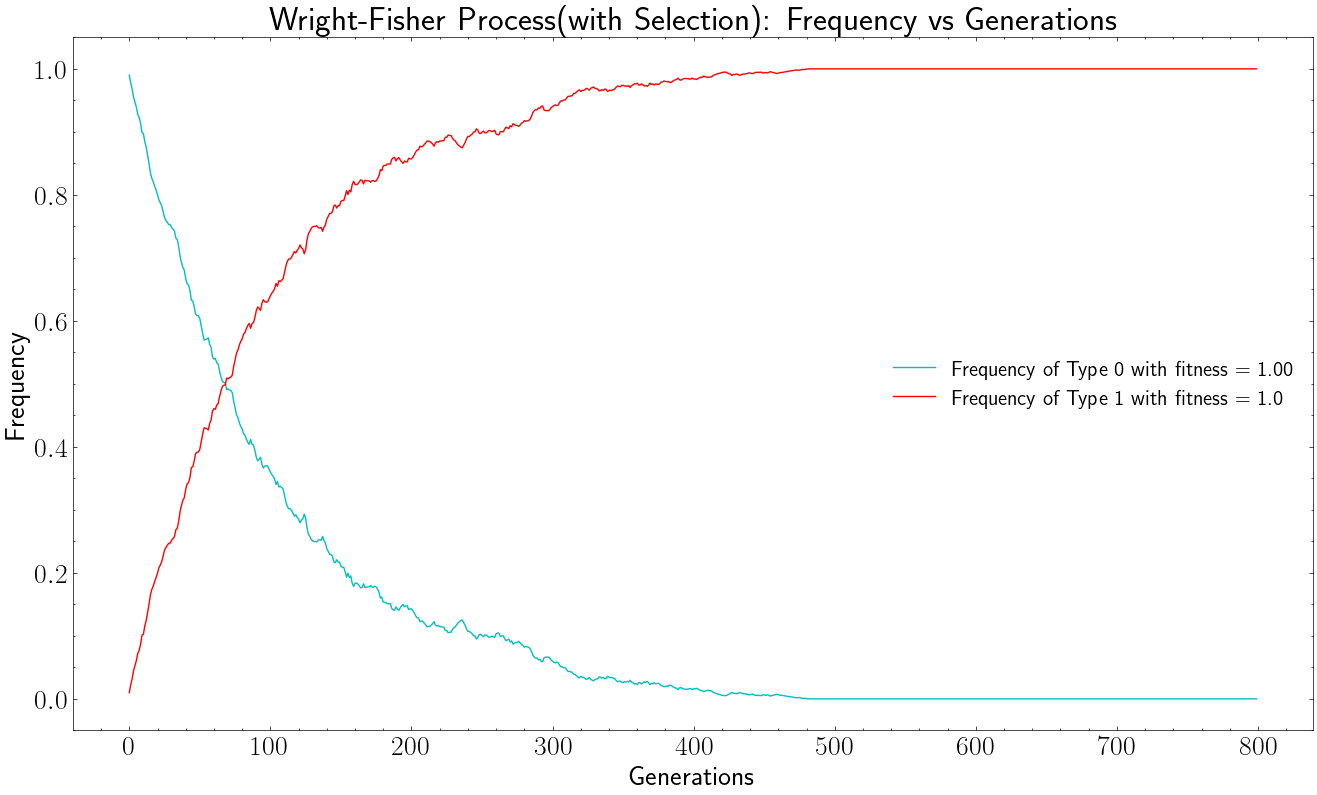

In [99]:
fig, axes = plt.subplots(figsize=(16,9))
axes.plot(freq[:,0], label=f"Frequency of Type 0 with fitness = {r:.2f}", color='c')
axes.plot(freq[:,1], label=f"Frequency of Type 1 with fitness = {1.0}", color='r')
axes.legend()
axes.set_xlabel("Generations")
axes.set_ylabel("Frequency")
axes.set_title("Wright-Fisher Process(with Selection): Frequency vs Generations")
fig.savefig("images/selmut_p1.png", dpi=300)

In [100]:
# population size
N_wf = 10000

# Maximum number of generations(to prevent infinite loops)
T_max = int(1e3)

# Relative fitness of type 0 compared to type 1
r = 1.1

# Mutation rate from type 0 to 1
u = 0.01

In [101]:
%%time

# This cell is not essential for the assignment, 
# It is just here to compile the njit function before we run the actual simulations in the next cell.

# Initial frequency of type A and type B in the population
freq = [0.5, 0.5]

pop0 = np.zeros(N_wf, dtype=int)
pop0[:int(N_wf//2)] = 1

# Run the Wright-Fisher process
freq = wright_fisher_process(freq,N_wf,r,T_max,pop0, mutation_rate)

# final frequency of type A and type B in the population
freq[-1]
  

Maximum generations reached without fixation
CPU times: user 5.98 s, sys: 1.96 ms, total: 5.98 s
Wall time: 6.02 s


array([0.8962, 0.1038])

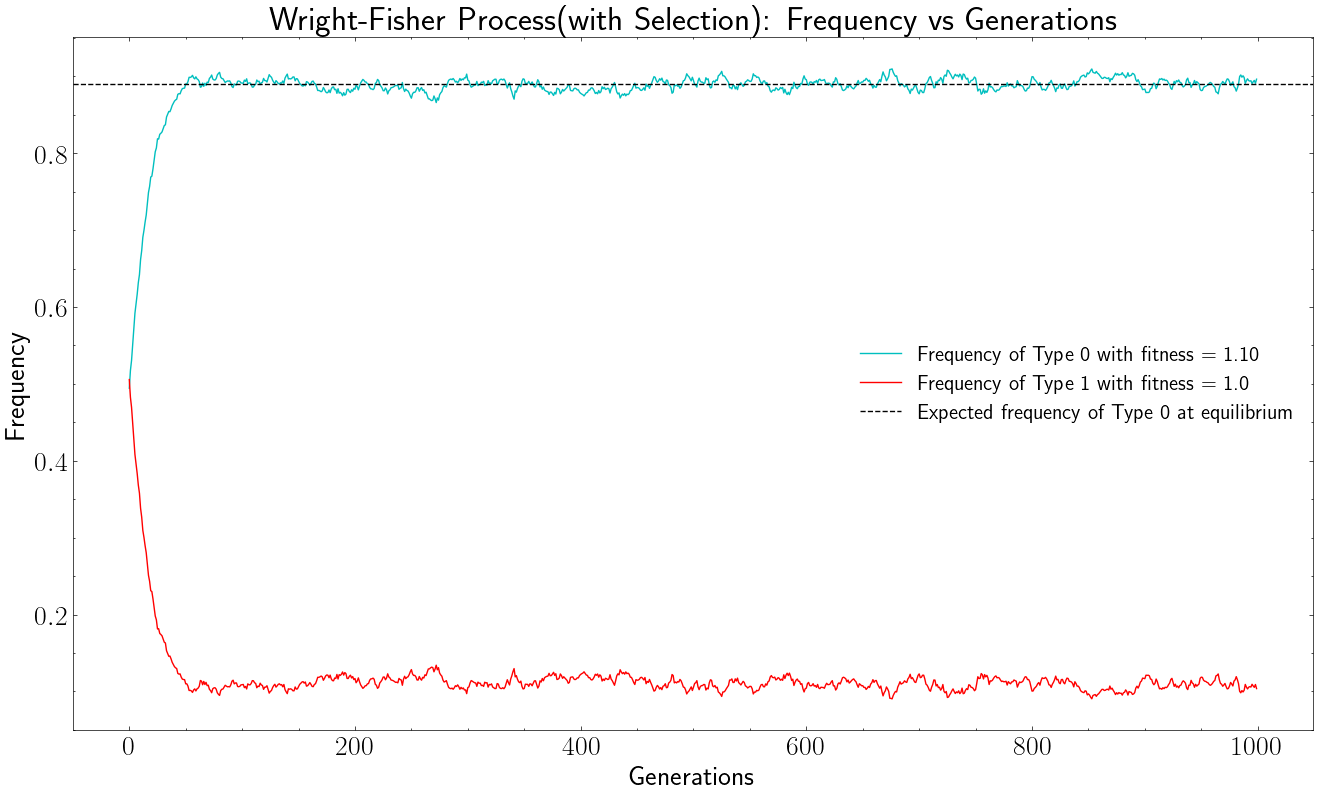

In [103]:
fig, axes = plt.subplots(figsize=(16,9))
axes.plot(freq[:,0], label=f"Frequency of Type 0 with fitness = {r:.2f}", color='c')
axes.plot(freq[:,1], label=f"Frequency of Type 1 with fitness = {1.0}", color='r')
axes.axhline(0.89,lw=1,color='k',ls='--', label="Expected frequency of Type 0 at equilibrium")
axes.legend()
axes.set_xlabel("Generations")
axes.set_ylabel("Frequency")
axes.set_title("Wright-Fisher Process(with Selection): Frequency vs Generations")
fig.savefig("images/selmut_p2.png", dpi=300)

In [108]:
# population size
N_wf = 1000

# Maximum number of generations(to prevent infinite loops)
T_max = int(1e3)

# Relative fitness of type 0 compared to type 1
r = 1.1

# Mutation rate from type 0 to 1
u = 0.01

In [109]:
%%time

# This cell is not essential for the assignment, 
# It is just here to compile the njit function before we run the actual simulations in the next cell.

# Initial frequency of type A and type B in the population
freq = [0.5, 0.5]

pop0 = np.zeros(N_wf, dtype=int)
pop0[:int(N_wf//2)] = 1


# Run the Wright-Fisher process
freq = wright_fisher_process(freq,N_wf,r,T_max,pop0, mutation_rate)

# final frequency of type A and type B in the population
freq[-1]
  

Maximum generations reached without fixation
CPU times: user 558 ms, sys: 1.8 ms, total: 560 ms
Wall time: 562 ms


array([0.898, 0.102])

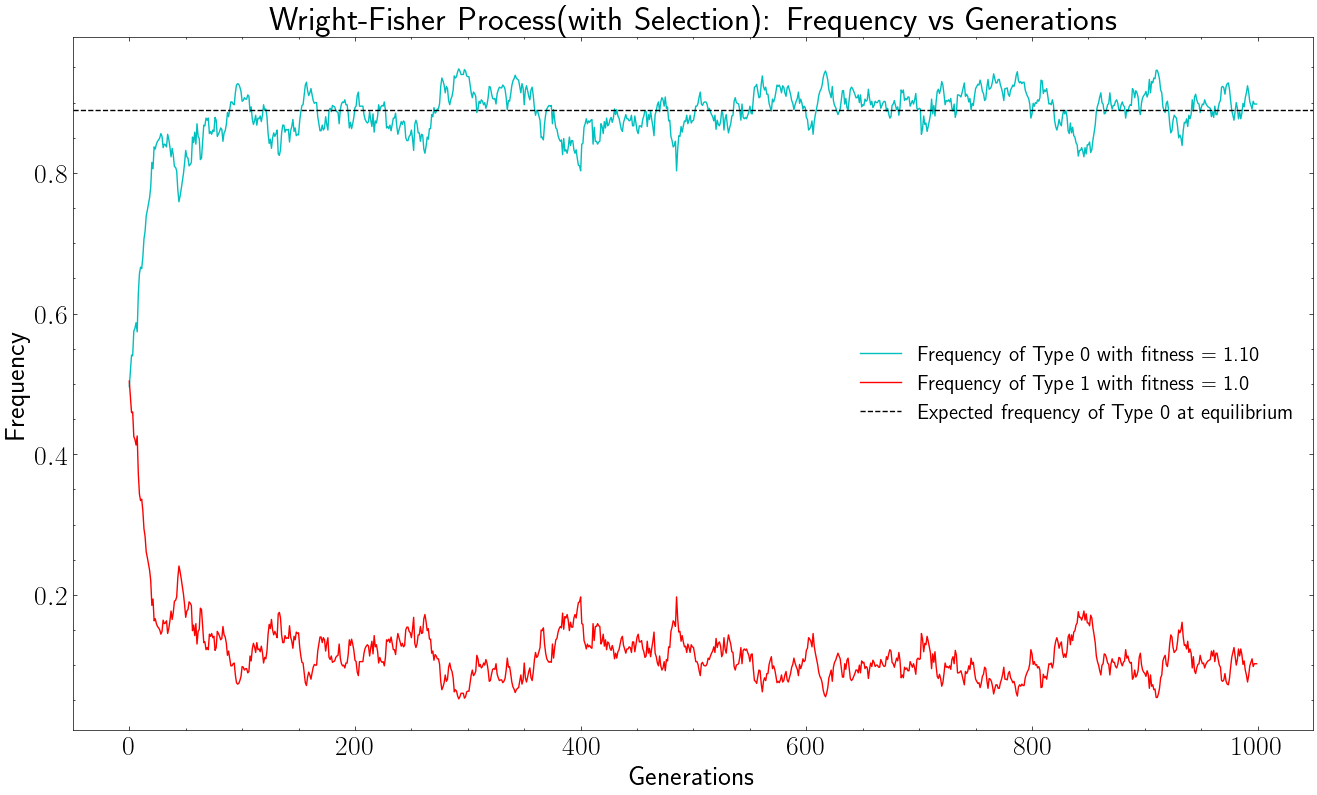

In [110]:
fig, axes = plt.subplots(figsize=(16,9))
axes.plot(freq[:,0], label=f"Frequency of Type 0 with fitness = {r:.2f}", color='c')
axes.plot(freq[:,1], label=f"Frequency of Type 1 with fitness = {1.0}", color='r')
axes.axhline(0.89,lw=1,color='k',ls='--', label="Expected frequency of Type 0 at equilibrium")
axes.legend()
axes.set_xlabel("Generations")
axes.set_ylabel("Frequency")
axes.set_title("Wright-Fisher Process(with Selection): Frequency vs Generations")
fig.savefig("images/selmut_p4.png", dpi=300)